# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 04: Transformações dos Dados (Pré-processamento)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                              | Local           |
|-------------------------------|---------------|-----------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_04_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='cyan'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/</font>

O conjunto de dados em questão é um dataset da área de negócios, especificamente do dominio de e-commerse, que tem como objetivo prever a intenção de ompra de consumidores durante sessões de navegação de um site de varejo online. O dataset contem informações detalhadas sobre 12.330 sessões de usuários diferentes ao longo de um ano, incluindo dados sobre páginas visitadas, temgasto em cada tipo de página, métricas do Google Analytics, informações sobre datas especiais, dados do usuário e um indicador binário que mostra se a sessão resultou ou não em compra.

## <font color='green'>Preparação</font>

In [71]:
!pip install pandas scikit-learn ucimlrepo

In [53]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=468)

_X_uci = ds.data.features
_y_uci = ds.data.targets

df = pd.concat([_X_uci, _y_uci], axis='columns')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='cyan'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Essa ação causaria um vazamento de dados, ao aplicar qualquer tipo de transformação no dataset, as estatísticas calculadas considaram também o conjunto teste que não deveria ser acessado durante o treinamento do modelo, isso resulta em uma avaliação não realista do desempenho.

### <font color='cyan'>Q2: Utilizando a função `train_test_split` biblioteca `scikit-learn`, divida as variáveis independentes (`X`) e a variável alvo (`y`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [54]:
from sklearn.model_selection import train_test_split

#Separaras variáveis independentes (X) e variável alvo (Y)
X = df.drop('Revenue', axis=1)
Y = df['Revenue']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
    )
print(f"Tamanho do conjunto de treino: {X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")
print(f"\nDistribuição da variável alvo no treino:")
print(Y_train.value_counts(normalize=True))
print(f"\nDistribuição da variável alvo no teste:")
print(Y_test.value_counts(normalize=True))

Tamanho do conjunto de treino: (9864, 17)
Tamanho do conjunto de teste: (2466, 17)

Distribuição da variável alvo no treino:
Revenue
False    0.845296
True     0.154704
Name: proportion, dtype: float64

Distribuição da variável alvo no teste:
Revenue
False    0.845093
True     0.154907
Name: proportion, dtype: float64


## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='cyan'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_train`).</font>

In [55]:
list(X_train.select_dtypes(include=['object', 'bool']).columns)

['Month', 'VisitorType', 'Weekend']

As variáveis categóricas identificadas foram Month, VisitorType e Weekend

### <font color='cyan'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras originais.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [56]:
X_train["Month"].sample(10, random_state=42)

,Month
4262,May
3161,May
10535,Dec
2586,May
1643,Mar
520,Mar
9298,Nov
8782,Nov
6023,Aug
8152,Dec


### <font color='cyan'>Q5: Aplique a técnica de `One-Hot Encoding` na variável escolhida utilizando a biblioteca scikit-learn.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='cyan'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [57]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

month_train_encoded = encoder.fit_transform(X_train[["Month"]])

month_test_encoded = encoder.transform(X_test[["Month"]])



### <font color='cyan'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='cyan'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [58]:
colunas =  encoder.get_feature_names_out(['Month'])
df_encoded = pd.DataFrame(month_train_encoded, columns=colunas)
df_encoded.sample(10, random_state=42)

,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
9746,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
500,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4852,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
872,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6202,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7690,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4306,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1078,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8568,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='cyan'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Esses algoritmos são sensíveis as escalas de dados. Variáveis com valores maiores dominam o cálculo da distância, prejudicando o modelo. o escalonamento garante que todos contribuam igualmente.

### <font color='cyan'>Q8: Selecione uma coluna numérica contínua de `X_train`. Escreva o nome da característica selecionada abaixo.</font>

In [59]:
X_train.select_dtypes(include=['int64', 'float64'])


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
4263,8,732.250000,0,0.0,34,1345.755952,0.005128,0.013342,12.274195,0.8,3,3,3,2
5905,0,0.000000,0,0.0,4,157.200000,0.040000,0.100000,0.000000,0.0,1,8,3,1
9434,0,0.000000,0,0.0,4,42.000000,0.000000,0.050000,0.000000,0.0,2,10,1,2
3505,2,338.000000,0,0.0,17,1205.566667,0.012500,0.037500,19.236250,0.8,3,2,2,2
2067,0,0.000000,0,0.0,32,827.646212,0.000000,0.000587,54.676348,0.0,2,2,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2419,4,69.000000,1,0.0,19,580.500000,0.010526,0.049123,22.329347,0.0,2,2,1,3
1200,4,16.666667,0,0.0,68,2593.741667,0.002941,0.012843,0.000000,0.0,2,2,4,8
2398,0,0.000000,0,0.0,17,433.133333,0.023529,0.051961,0.000000,1.0,3,2,4,4
11106,0,0.000000,0,0.0,73,2784.800000,0.002740,0.015318,6.135982,0.0,2,2,5,2


In [60]:
col = 'Administrative_Duration'

### <font color='cyan'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [61]:
X_train[col].describe()

,Administrative_Duration
count,9864.000000
mean,81.241059
std,179.610421
min,0.000000
25%,0.000000
50%,8.000000
75%,93.000000
max,3398.750000


Média (mean) -> 81.241059,
Mediana (50%) -> 8,
Desvio padrão (std) -> 179.610421,
Minímo (min) -> 0,
Máximo (max) -> 3398.750000


### <font color='cyan'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

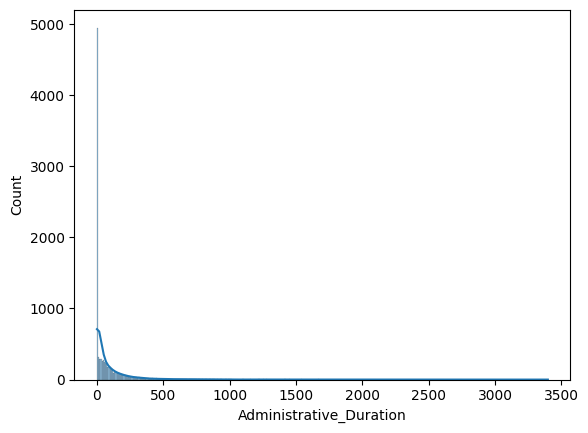

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(X_train[col], kde=True)
plt.show()

### <font color='cyan'>Q11: Aplique o Escalonamento nesta variável. Você pode escolher entre a Padronização (`StandardScaler`) ou a Normalização (`MinMaxScaler`), ambas da biblioteca scikit-learn.</font>

- #### <font color='cyan'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_train` e `X_test`) pelos valores escalonados.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>

In [63]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
X_train[col] = scaler.fit_transform(X_train[[col]])

X_test[col] = scaler.transform(X_test[[col]])

### <font color='cyan'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [64]:
X_train[col].describe()

,Administrative_Duration
count,9.864000e+03
mean,-2.125001e-17
std,1.000051e+00
min,-4.523411e-01
25%,-4.523411e-01
50%,-4.077980e-01
75%,6.547246e-02
max,1.847152e+01


### <font color='cyan'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

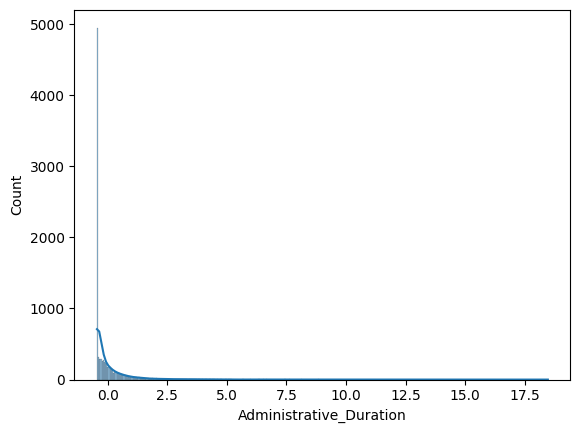

In [65]:
sns.histplot(X_train[col], kde=True)
plt.show()

### <font color='cyan'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='cyan'>O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='cyan'>O que aconteceu com a escala do eixo X e com o formato da curva no gráfico?</font>

Após aplicar o escalonamento a média se aproximos do 0 e o desvio padrão d e11 (justamente o objetivo desse método). Com isso os valores foram passado para uma faixa menor , reduzindo a magnitude dos dados, porém, o formato da distribuição permaneceu praticamnte o mesmo, amntendo sua assimetria e cauda longa a  direita.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='cyan'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='cyan'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [66]:
X_train['Total_Abandon'] = X_train['BounceRates'] + X_train['ExitRates']
X_test['Total_Abandon'] = X_test['BounceRates'] + X_test['ExitRates']

Essa variável representa o compotamento de abandono do usuário, combinando taxas de saídas e rejeição.

### <font color='cyan'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [67]:
X_train['Total_Abandon'].sample(10, random_state=42)

,Total_Abandon
4262,0.012308
3161,0.010526
10535,0.027451
2586,0.046154
1643,0.019932
520,0.033333
9298,0.025986
8782,0.012121
6023,0.018621
8152,0.040000


### <font color='cyan'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_train`).</font>
- #### <font color='cyan'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='cyan'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='cyan'>Importante: Utilize o `LabelEncoder` da biblioteca `scikit-learn` para transformar a variável alvo (`y_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y_train_num = le.fit_transform(Y_train)
corr = pd.Series(X_train['Total_Abandon']).corr(pd.Series(Y_train_num))

print(f"Correlação de Pearson: {corr}")

Correlação de Pearson: -0.000938563578357757


A correlação e Pearson deu um valor negativo porém muito próximo de 0, ou seja é uma correlação muito fraca (|r| < 0.1 -> correlação muito fraca,quase inexistente) e praticamente sem relação linear, Portanto, esse atributo, isoladamente provavelmente não contribuirá de forma relevante para o desemprenho de um modelo de aprendizado de máquina.

## <font color='green'>**3.5 Extração / Seleção de Atributos**</font>

### <font color='cyan'>Q18: Qual a principal diferença conceitual entre Extração de Atributos (ex: `Principal Component Analysis`) e Seleção de Atributos (ex: `Variance Threshold`)? Explique.</font>

A extração e atributos cria novas variáveis a partir das origiinais enquanto a seleção de atributos escolhe apenas algumas variáveis existentes.

### <font color='cyan'>Q19: Aplique a técnica de Análise de Componentes Principais (PCA) em todas as variáveis numéricas escalonadas.</font>

- #### <font color='cyan'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis) e ajuste-o aos dados de treinamento.</font>
- #### <font color='cyan'>b) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='cyan'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='cyan'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='cyan'>c) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

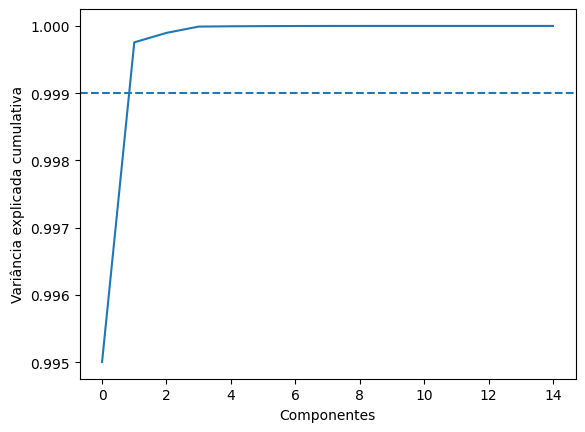

In [69]:
from sklearn.decomposition import PCA
import numpy as np

X_num = X_train.select_dtypes(include=['int64', 'float64'])
pca = PCA()
pca.fit(X_num)

variancia =  np.cumsum(pca.explained_variance_ratio_)

plt.plot(variancia)
plt.axhline(y=0.999, linestyle='--')
plt.xlabel("Componentes")
plt.ylabel("Variância explicada cumulativa")
plt.show()

A quantidade mínima para atingir o critério de 99,9% de variância é de 2 componetes principais. A escolha de um limiar tão alto garante que praticamente toda a informação presente nos dados originais seja preservada.

### <font color='cyan'>Q20: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='cyan'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='cyan'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='cyan'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='cyan'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [70]:
k = np.argmax(variancia>= 0.999) + 1
pca_final = PCA(n_components=k)
X_train_pca = pca_final.fit_transform(X_num)
X_test_pca = pca_final.transform(X_test[X_num.columns])

print(f"Shape dos dados antes da transformação: {X_num.shape}")
print(f"Shape dos dados depois da transformação: {X_train_pca.shape}")

componentes =  pd.Series(pca_final.components_[0], index=X_num.columns)
componentes.abs().sort_values(ascending=False).head(3)

Shape dos dados antes da transformação: (9864, 15)
Shape dos dados depois da transformação: (9864, 2)


,0
ProductRelated_Duration,0.999454
Informational_Duration,0.026647
ProductRelated,0.019492


A análise dos coeficientes da PC1 mostra que o atributo mais influente é o ProductRelated_Duration, seguido do Informational_Duration e do ProductRelated. Indicando que a variabilidade dos dados é fortemente dominada pelo tempo tempo gasto em páginasrelacionadas a produtos.